# Run N4 Bias Correction on MAMA-MIA data

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/jarvais-breast


In [2]:
import pandas as pd
from damply import dirs

from imgtools.transforms.functional import bias_correction
import SimpleITK as sitk

In [3]:
mr_path = "data/procdata/Breast/BCN-AIM_MAMA-MIA/images/aaura_MAMA-MIA_no-bias-correction/DUKE_001/MR.nii.gz"
mask_path = "data/procdata/Breast/BCN-AIM_MAMA-MIA/images/aaura_MAMA-MIA_no-bias-correction/DUKE_001/mask_1.nii.gz"

mr_scan = sitk.ReadImage(mr_path)
print(mr_scan.GetPixelIDTypeAsString())

mask = sitk.ReadImage(mask_path)

32-bit signed integer


In [4]:
bc_mr_path = "data/procdata/Breast/BCN-AIM_MAMA-MIA/images/bias_correct_MAMA-MIA/DUKE_001_MR.nii.gz"

bc_mr_scan = sitk.ReadImage(bc_mr_path)
bc_mr_scan.GetPixelIDTypeAsString()

'32-bit float'

In [ ]:
# bc_mr_scan = bias_correction(sitk.Cast(mr_scan, sitk.sitkFloat32))
# sitk.WriteImage(bc_mr_scan, "data/procdata/Breast/BCN-AIM_MAMA-MIA/images/bias_correct_MAMA-MIA/DUKE_001_MR.nii.gz")

In [5]:
from imgtools.vizualize import view_multiple_SliceImage3DObjects, ImageVisualizer

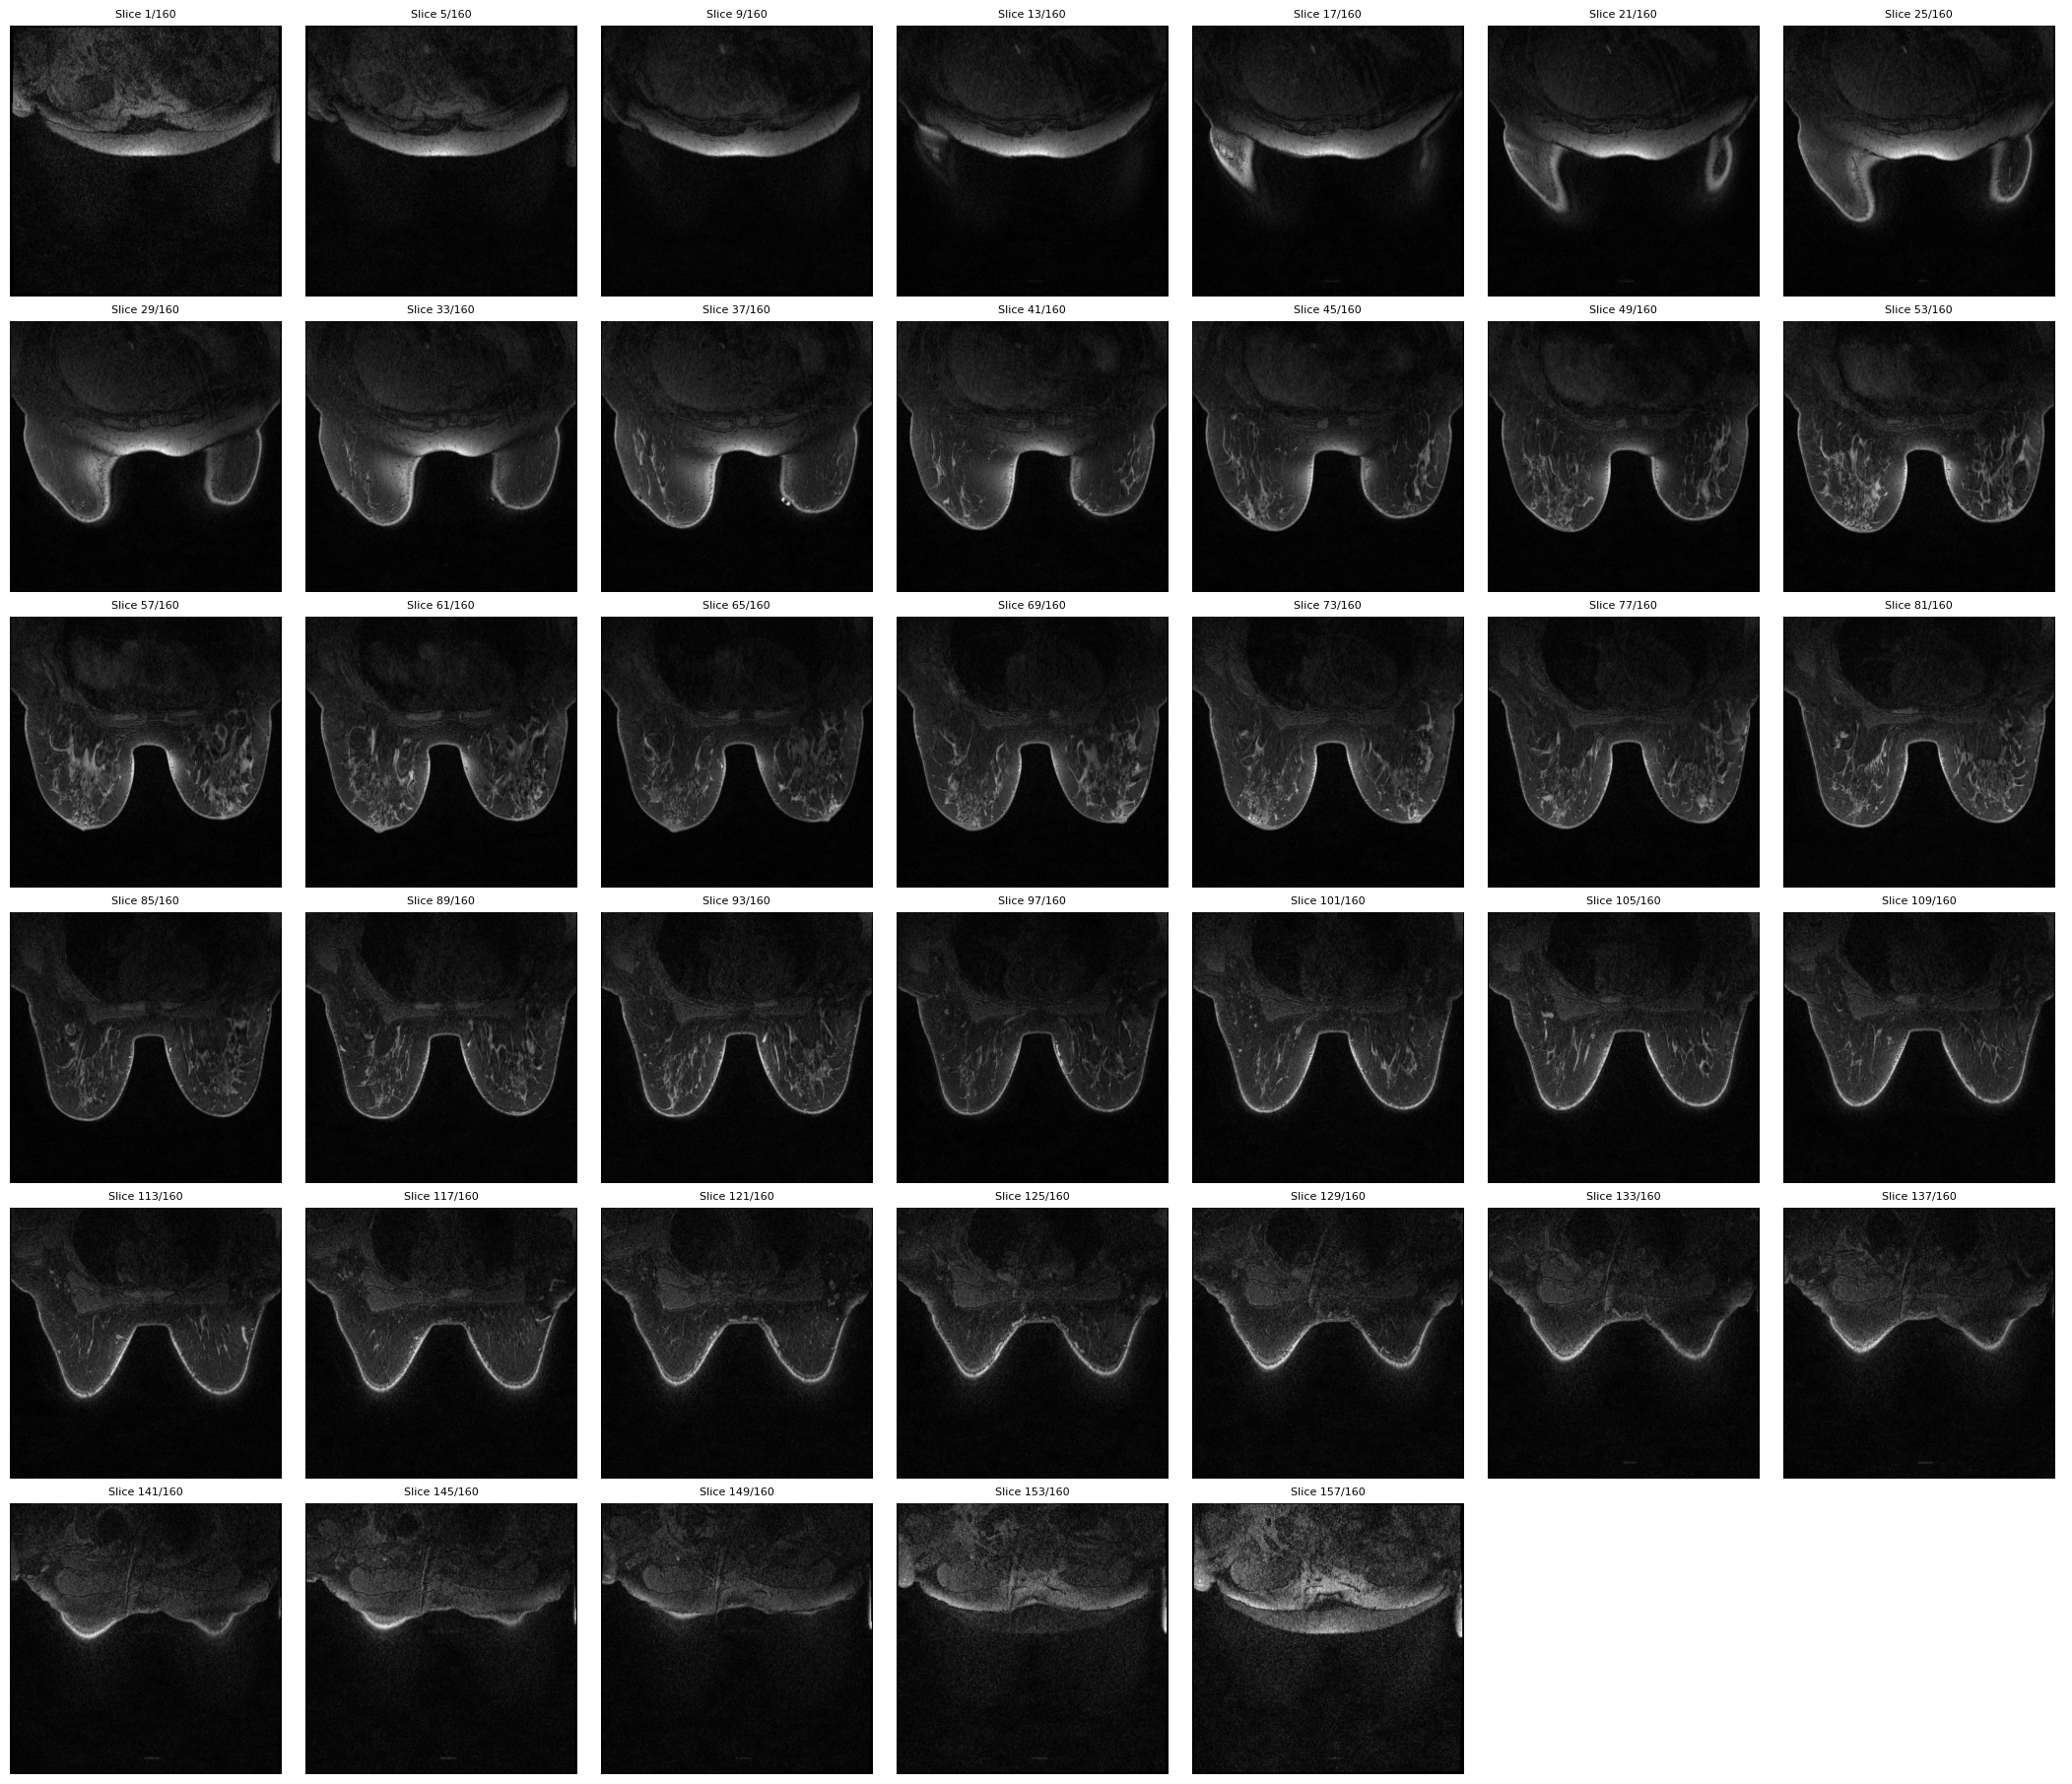

In [11]:
viz = ImageVisualizer(bc_mr_scan)
slice_grid = viz.view_grid(4)

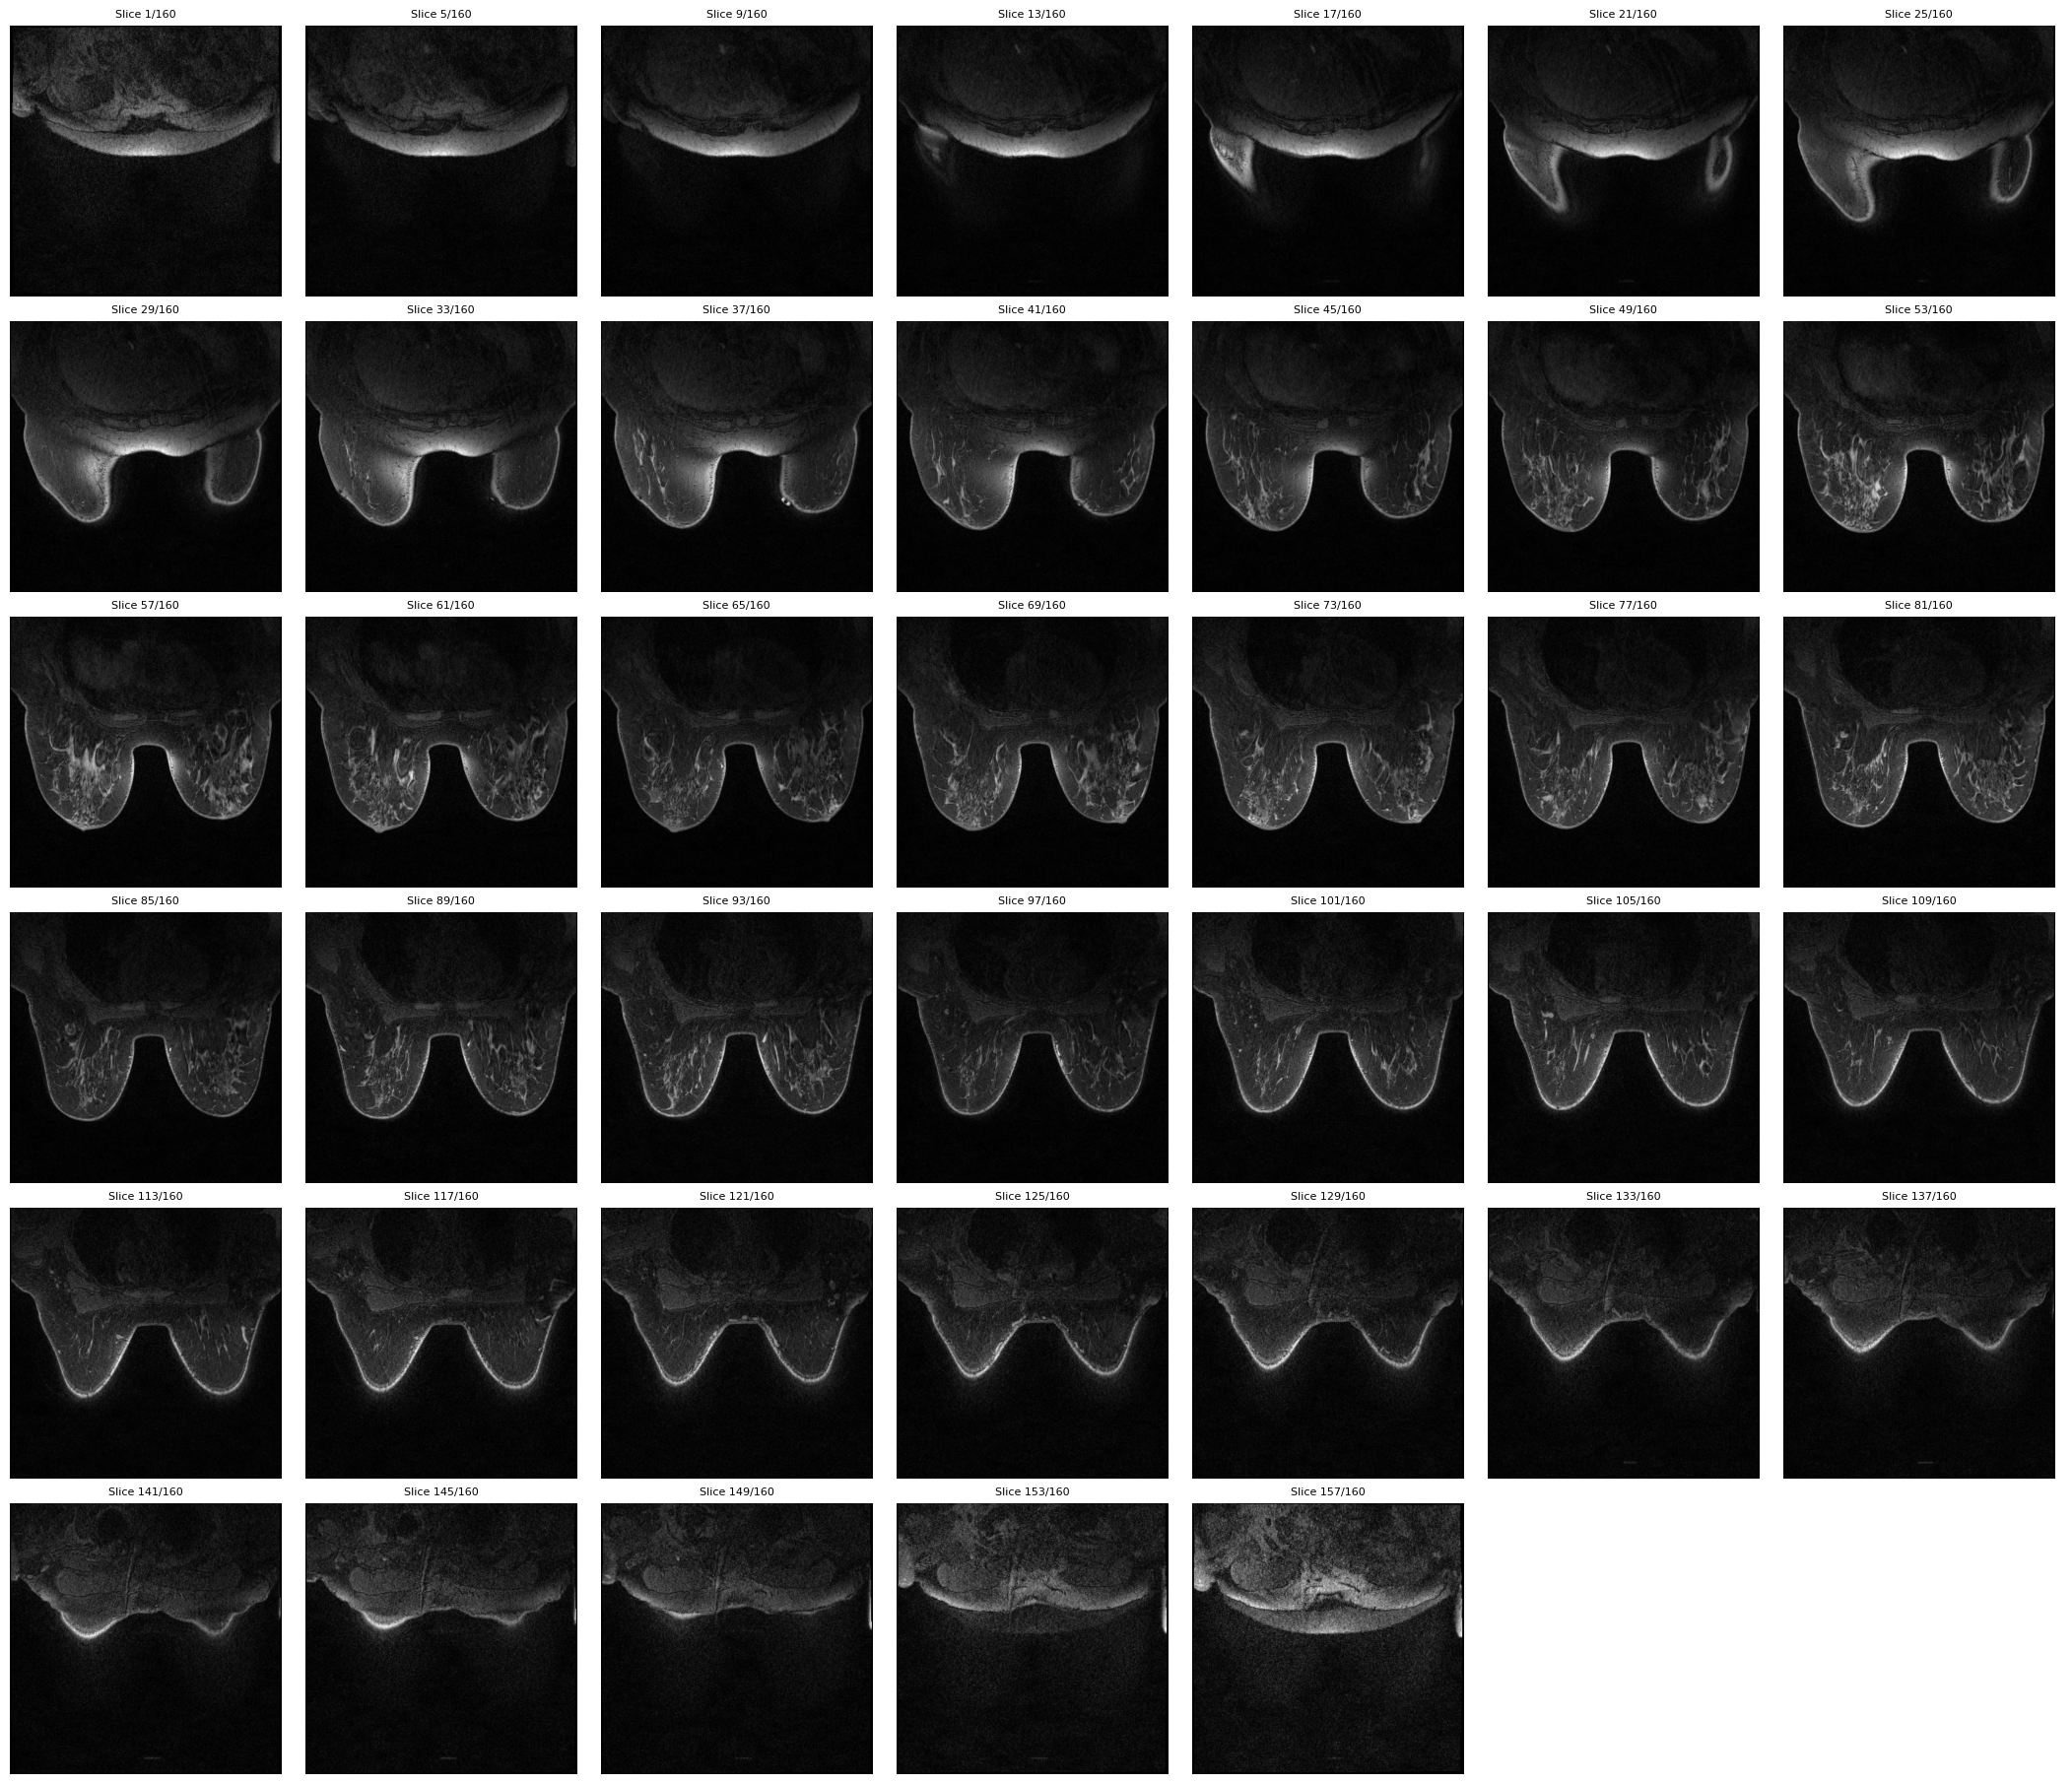

In [16]:
raw_viz = ImageVisualizer(mr_scan)

raw_slice_grid = raw_viz.view_grid(4)

In [17]:
np_bc_scan = sitk.GetArrayFromImage(bc_mr_scan)

np_bc_scan.min()

0.0

In [18]:
np_bc_scan.max()

268.25916

In [17]:
mr_scan.GetSize()

(448, 448, 160)

In [6]:
from imgtools.vizualize import SliceImage3D

raw_image = SliceImage3D(mr_scan, mask).generate_dim_slices(dim=0)

view_multiple_SliceImage3DObjects(('raw', raw_image))

11:31:06 [warning  ] Generating slices...           [imgtools] call=visualizer.generate_dim_slices:151


  0%|          | 0/32 [00:00<?, ?it/s]

interactive(children=(IntSlider(value=15, description='index', max=31), Output()), _dom_classes=('widget-inter…

In [7]:
bc_image = SliceImage3D(bc_mr_scan, mask).generate_dim_slices(dim=0)
view_multiple_SliceImage3DObjects(('bias corrected', bc_image))

11:31:10 [warning  ] Generating slices...           [imgtools] call=visualizer.generate_dim_slices:151


  0%|          | 0/32 [00:00<?, ?it/s]

interactive(children=(IntSlider(value=15, description='index', max=31), Output()), _dom_classes=('widget-inter…